<a href="https://colab.research.google.com/github/joluva/datascience/blob/main/API4_Vasquez_Jorge_Luis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COMIENZA LA IMPORTACION DE LIBRERIAS NECESARIAS

In [ ]:
# api-4 importamos las librerias necesarias, pandas, numpy, matplotlib, seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

%matplotlib inline


PREPARO LOS DATA FRAME DE LAS DISTINTAS BASES

In [ ]:
# armo los dame de las distintas bases
empleo = pd.read_csv('empleo.csv', encoding='latin1')
esperanza=pd.read_csv('esperanza_de_vida.csv', encoding='latin1')
exportaciones=pd.read_csv('exportaciones.csv', encoding='latin1')
hogares=pd.read_csv('hogares_viviendas_superficie.csv', encoding='latin1')
poblacion=pd.read_csv('poblacion.csv', encoding='latin1')

CREO UNA FUNCION QUE SE ENCARGA DE RECIBIR LOS DF Y MOSTRAR INFORMACION

In [ ]:
# armo una funcion para mostrar los cheos basicos de cada base
def chequeos_basicos(lista_df):
  for nombre, df in lista_df.items():
    print(f'Chequeo básico para el data set de: {nombre} \n')
    print('\nNumero filas y columnas : \n')
    print(df.shape)
    print('\nPrimeras filas :  \n')
    print(df.head())
    print('\nUltimas filas : \n')
    print(df.tail())
    print('\nTipos de datos : \n')
    print(df.dtypes)
    print('\nNumeros faltantes por columnas : \n')
    print(df.isnull().sum())
    print('\nNumero de duplicados : \n')
    print(df.duplicated().sum())
    print('--' * 20)

PREPARO UN DICCIONARIO CON LOS DF A MOSTRAR Y SE LOS PASO A LA FUNCIÓN

In [ ]:
# creo el diccionario con los data frame
diccionario = {'empleo': empleo, 'esperanza': esperanza, 'exportaciones': exportaciones, 'hogares': hogares, 'poblacion': poblacion}

# llamo a la función que muestra la informacion de los DF
chequeos_basicos(diccionario)

Chequeo básico para el data set de: empleo 


Numero filas y columnas : 

(3696, 4)

Primeras filas :  

      provincia  anio     mes  empleados_registrados_miles
0  Buenos Aires  2009  ene-09                     1787.640
1  Buenos Aires  2009  feb-09                     1769.223
2  Buenos Aires  2009  mar-09                     1745.913
3  Buenos Aires  2009  abr-09                     1729.917
4  Buenos Aires  2009  may-09                     1723.218

Ultimas filas : 

     provincia  anio     mes  empleados_registrados_miles
3691   Tucumán  2021  jun-21                      172.053
3692   Tucumán  2021  jul-21                      172.030
3693   Tucumán  2021  ago-21                      171.015
3694   Tucumán  2021  sep-21                      168.084
3695   Tucumán  2021  oct-21                      165.578

Tipos de datos : 

provincia                       object
anio                             int64
mes                             object
empleados_registrados_miles    float6

#### COMBINO LOS DATE FRAME POBLACION CON HOGARES

In [ ]:
# aca combino los dataframe poblacion con hogares
poblac_superf = pd.merge(poblacion, hogares, left_on='provincia', right_on='provincia', how='left')
poblac_superf = poblac_superf[poblac_superf['provincia'] != 'Total País']
#poblac_superf = poblac_superf.drop(['index'], axis=1)
poblac_superf

,provincia,anio,poblacion_total,poblacion_varones,poblacion_mujeres,provincia_id,hogares,viviendas_particulares,viviendas_particulares_habitadas,superficie_km2
31,Capital Federal,2010,3028481,1405566,1622915,2.0,1150134.0,1423973.0,1082998.0,200.0
32,Capital Federal,2011,3033639,1409835,1623804,2.0,1150134.0,1423973.0,1082998.0,200.0
33,Capital Federal,2012,3038860,1414105,1624755,2.0,1150134.0,1423973.0,1082998.0,200.0
34,Capital Federal,2013,3044076,1418339,1625737,2.0,1150134.0,1423973.0,1082998.0,200.0
35,Capital Federal,2014,3049229,1422507,1626722,2.0,1150134.0,1423973.0,1082998.0,200.0
...,...,...,...,...,...,...,...,...,...,...
770,Tierra del Fuego,2036,241593,122567,119026,94.0,38956.0,43360.0,36689.0,1002445.0
771,Tierra del Fuego,2037,245734,124625,121109,94.0,38956.0,43360.0,36689.0,1002445.0
772,Tierra del Fuego,2038,249853,126670,123183,94.0,38956.0,43360.0,36689.0,1002445.0
773,Tierra del Fuego,2039,253948,128702,125246,94.0,38956.0,43360.0,36689.0,1002445.0


FILTRO LAS COLUMNAS RELEVANTES PARA EL ANALISIS

In [ ]:
# separo las columnas que necesito para hacer el análisis de hogares
columnas_relevantes = ['provincia', 'hogares', 'viviendas_particulares_habitadas', 'superficie_km2']
hogares_filtrado = hogares[columnas_relevantes]
hogares_filtrado


,provincia,hogares,viviendas_particulares_habitadas,superficie_km2
0,Capital Federal,1150134,1082998,200
1,Buenos Aires,4789484,4425193,307571
2,Catamarca,96001,89376,102602
3,Córdoba,1031843,978553,165321
4,Corrientes,267797,248844,88199
5,Chaco,288422,270133,99633
6,Chubut,157166,147176,224686
7,Entre Ríos,375121,357250,78781
8,Formosa,140303,130134,72066
9,Jujuy,174630,154911,53219


RDENAR LOS DATOS POR KM2


In [ ]:
# agrupo los datos de hogares_filtrado por superficie_km2 de forma ascendente
hogares_ordenados = hogares_filtrado.sort_values('superficie_km2', ascending=False)
hogares_ordenados

,provincia,hogares,viviendas_particulares_habitadas,superficie_km2
23,Tierra del Fuego,38956,36689,1002445
1,Buenos Aires,4789484,4425193,307571
19,Santa Cruz,81796,76233,243943
6,Chubut,157166,147176,224686
15,Río Negro,199189,190597,203013
3,Córdoba,1031843,978553,165321
16,Salta,299794,267075,155488
12,Mendoza,494841,459550,148827
10,La Pampa,107674,104797,143440
21,Santiago del Estero,218025,197906,136351


AGREGACIONES - CALCULAR PROMEDIOS

In [ ]:
# calcular el promedio de hogares en todo el pais
hogares_promedio_pais = hogares_ordenados['hogares'].mean()
print("\nPromedio de hogares en todo el pais:")
print(hogares_promedio_pais)


Promedio de hogares en todo el pais:
507153.125


In [ ]:
# calcular el promedio de viviendas_particulares_habitadas de todo el pais
viviendas_promedio_pais = hogares_ordenados['viviendas_particulares_habitadas'].mean()
print("\nPromedio de viviendas particulares habitadas en todo el pais:")
print(viviendas_promedio_pais)



Promedio de viviendas particulares habitadas en todo el pais:
471562.7916666667


EXAMINAR LA DISTRIBUCION DE DATOS

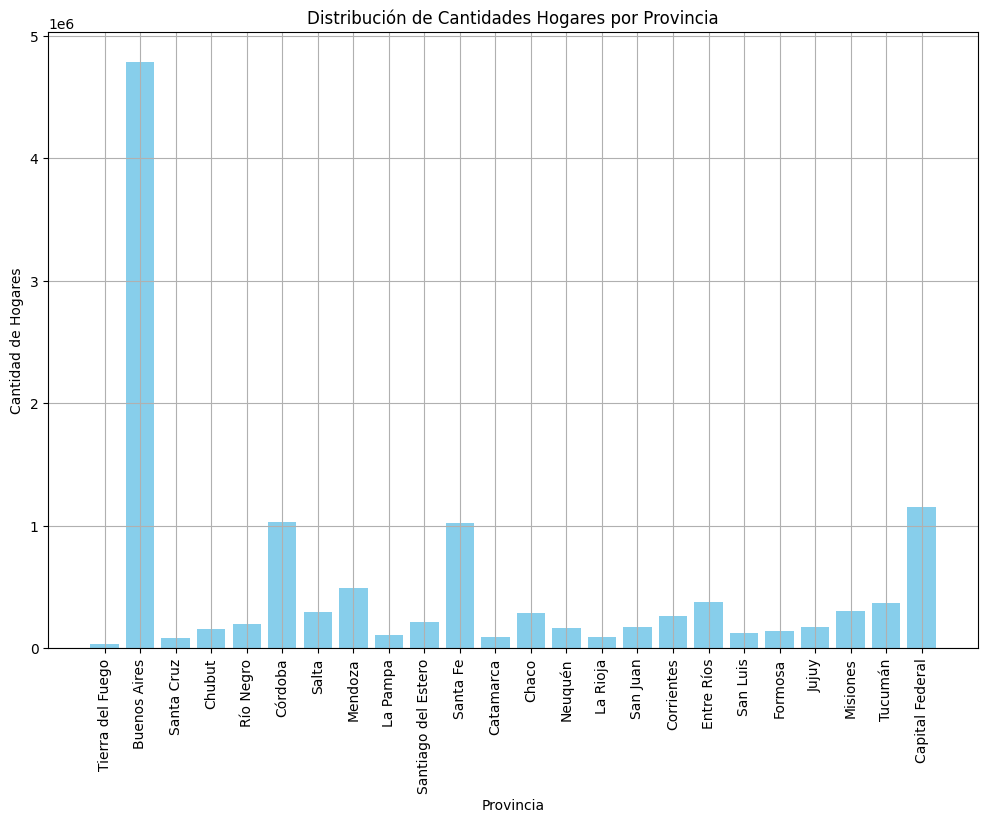

In [ ]:
# grafico de barras de la cantidad de hogares por provincia
plt.figure(figsize=(12, 8))
plt.bar(hogares_ordenados['provincia'], hogares_ordenados['hogares'], color='skyblue') #, edgecolor='black')
plt.title('Distribución de Cantidades Hogares por Provincia')
plt.xlabel('Provincia')
plt.ylabel('Cantidad de Hogares')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

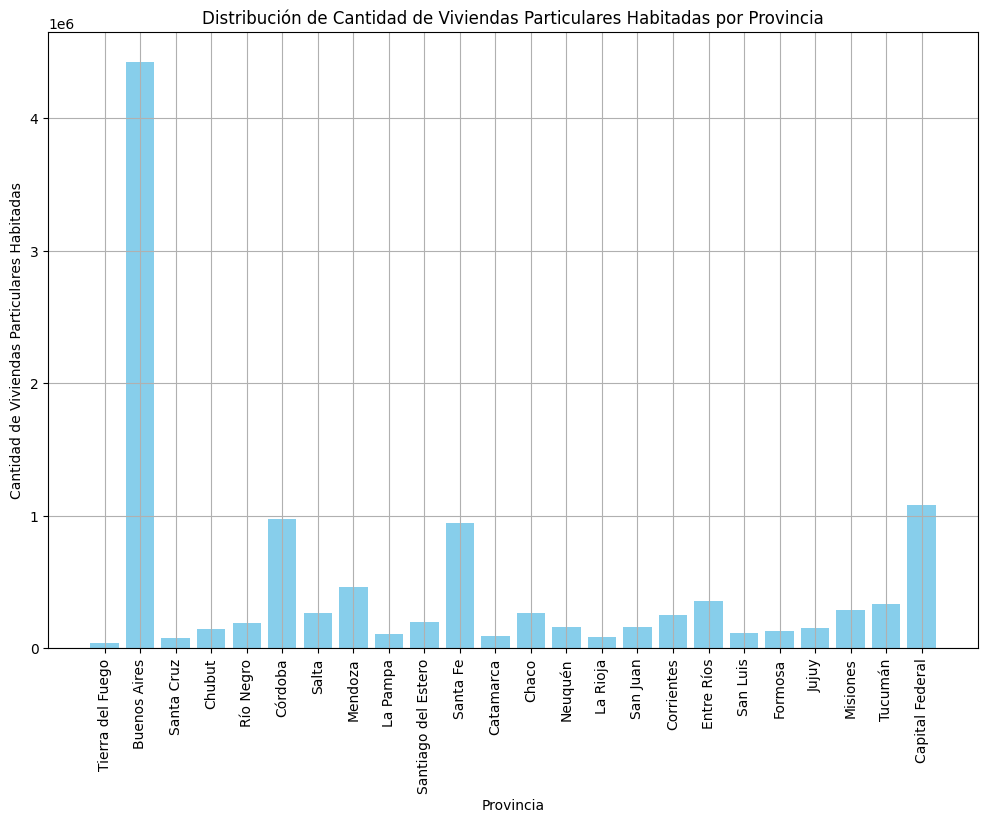

In [ ]:
# grafico de barras de la cantidad de viviendas_particulares_habitadas por provincia
plt.figure(figsize=(12, 8))
plt.bar(hogares_ordenados['provincia'], hogares_ordenados['viviendas_particulares_habitadas'], color='skyblue') #, edgecolor='black')
plt.title('Distribución de Cantidad de Viviendas Particulares Habitadas por Provincia')
plt.xlabel('Provincia')
plt.ylabel('Cantidad de Viviendas Particulares Habitadas')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

### CALCULAR LA DENSIDAD DE HOGARES Y VIVIENDAS PARTICULARES HABITADAS

In [ ]:
# calculo la densidad de hogares y viviendas_particulares_habitadas en base a la superficie en km2
hogares_ordenados['densidad_hogares'] = hogares_ordenados['hogares'] / hogares_ordenados['superficie_km2']
hogares_ordenados['densidad_viviendas'] = hogares_ordenados['viviendas_particulares_habitadas'] / hogares_ordenados['superficie_km2']
hogares_ordenados

,provincia,hogares,viviendas_particulares_habitadas,superficie_km2,densidad_hogares,densidad_viviendas
23,Tierra del Fuego,38956,36689,1002445,0.038861,0.036600
1,Buenos Aires,4789484,4425193,307571,15.571962,14.387550
19,Santa Cruz,81796,76233,243943,0.335308,0.312503
6,Chubut,157166,147176,224686,0.699492,0.655030
15,Río Negro,199189,190597,203013,0.981164,0.938841
3,Córdoba,1031843,978553,165321,6.241451,5.919109
16,Salta,299794,267075,155488,1.928084,1.717657
12,Mendoza,494841,459550,148827,3.324941,3.087813
10,La Pampa,107674,104797,143440,0.750655,0.730598
21,Santiago del Estero,218025,197906,136351,1.598998,1.451445


### ANALISIS EXPLORATORIO DE HOGARES

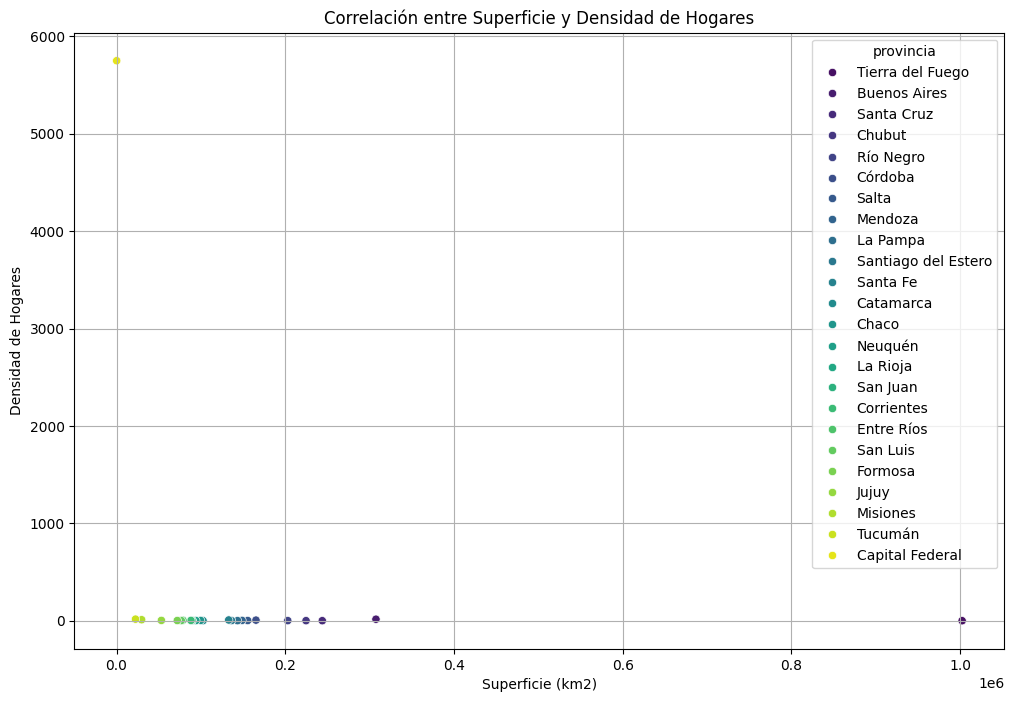

In [ ]:
# para analizar si la hipotesis es valida podemos analizar la correlacion entre superficie y densidad
plt.figure(figsize=(12, 8))
sns.scatterplot(x=hogares_ordenados['superficie_km2'], y=hogares_ordenados['densidad_hogares'], hue=hogares_ordenados['provincia'], palette='viridis' )#color='skyblue')
plt.title('Correlación entre Superficie y Densidad de Hogares')
plt.xlabel('Superficie (km2)')
plt.ylabel('Densidad de Hogares')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(hogares_ordenados, cbar=False,cmap='viridis')

ValueError: could not convert string to float: 'Tierra del Fuego'

<Figure size 1000x600 with 0 Axes>

### MIDO LA CORRELACION ESTADISTICA

In [ ]:
""" podemos usar la correlacion de Pearson para ver si existe una relación significativa
    Si el coeficiente es negativo y cercano a -1 significa que a mayor superficie,
    menor  densidad, lo que apoyaría la hipotesis.
    Si el resultado es cercano a 0, entonces no hay una correlación significativa.
"""
correlacion_hogares = hogares_ordenados[['superficie_km2', 'densidad_hogares']].corr(method='pearson')
print("Correlación de Pearson entre Superficie y Densidad de Hogares:", correlacion_hogares)

print('\n')

np.corrcoef(hogares_ordenados['superficie_km2'], hogares_ordenados['densidad_hogares'])

Correlación de Pearson entre Superficie y Densidad de Hogares:                   superficie_km2  densidad_hogares
superficie_km2          1.000000         -0.172442
densidad_hogares       -0.172442          1.000000




array([[ 1.        , -0.17244198],
       [-0.17244198,  1.        ]])

### BUSCAR VALORES ATIPICOS PARA VER QUE SUCEDE

In [ ]:
# buscar valores atipicos
p99_cantidad = np.percentile(hogares_ordenados['hogares'], 99)
p99_cantidad
hogares_ordenados[hogares_ordenados['hogares'] >= p99_cantidad]

,provincia,hogares,viviendas_particulares_habitadas,superficie_km2,densidad_hogares,densidad_viviendas
1,Buenos Aires,4789484,4425193,307571,15.571962,14.38755


## ARMO EL MISMO ANALISIS CON LA BASE DE EXPORTACIONES

In [ ]:

exportaciones_filtrado = exportaciones[(exportaciones['rubro'] == 'Total') & (exportaciones['provincia'] != 'Total País')]
exportaciones_filtrado

,rubro,provincia,anio,value
1,Total,Buenos Aires,2005,15626.865
2,Total,Capital Federal,2005,271.295
3,Total,Córdoba,2005,4452.178
4,Total,Entre Ríos,2005,815.341
5,Total,La Pampa,2005,242.874
...,...,...,...,...
1895,Total,San Luis,2020,568.631
1896,Total,Chaco,2020,375.96
1897,Total,Corrientes,2020,585.815
1898,Total,Formosa,2020,30.446


In [ ]:
#exportaciones_filtrado = exportaciones[(exportaciones['rubro'] != 'Total') & (exportaciones['provincia'] != 'Total País') &
                                   #(exportaciones['anio'] == 2020)]


exportaciones_filtrado = exportaciones[(exportaciones['rubro'] == 'Combustibles y energía') & (exportaciones['provincia'] != 'Total País')]
exportaciones_filtrado

,rubro,provincia,anio,value
101,Combustibles y energía,Buenos Aires,2005,2478.212
102,Combustibles y energía,Capital Federal,2005,0
103,Combustibles y energía,Córdoba,2005,0
104,Combustibles y energía,Entre Ríos,2005,0
105,Combustibles y energía,La Pampa,2005,23.334
...,...,...,...,...
1995,Combustibles y energía,San Luis,2020,0
1996,Combustibles y energía,Chaco,2020,0
1997,Combustibles y energía,Corrientes,2020,373.938
1998,Combustibles y energía,Formosa,2020,5.169


In [ ]:
# preparo los datos de las provincias productoras de combustibles, separo las filas cuyo value > 0
exportaciones_filtrado['value'] = pd.to_numeric(exportaciones_filtrado['value'], errors='coerce')
exportaciones_filtrado = exportaciones_filtrado[exportaciones_filtrado['value'] > 0]
exportaciones_filtrado

<ipython-input-70-6757f112fbc3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exportaciones_filtrado['value'] = pd.to_numeric(exportaciones_filtrado['value'], errors='coerce')


,rubro,provincia,anio,value
101,Combustibles y energía,Buenos Aires,2005,2478.212
105,Combustibles y energía,La Pampa,2005,23.334
106,Combustibles y energía,Santa Fe,2005,215.200
107,Combustibles y energía,Chubut,2005,1254.520
108,Combustibles y energía,Neuquén,2005,819.647
...,...,...,...,...
1990,Combustibles y energía,Salta,2020,19.106
1992,Combustibles y energía,Tucumán,2020,1.498
1993,Combustibles y energía,Mendoza,2020,33.993
1997,Combustibles y energía,Corrientes,2020,373.938


### VOY A SEPARAR LOS DATOS DE BUENOS AIRES

In [ ]:
# separo los datos de buenos aires para analizar las exportaciones en el tiempo
exportaciones_ba = exportaciones_filtrado[(exportaciones_filtrado['provincia'] == 'Buenos Aires') ]
exportaciones_ba

,rubro,provincia,anio,value
101,Combustibles y energía,Buenos Aires,2005,2478.212
226,Combustibles y energía,Buenos Aires,2006,2853.973
351,Combustibles y energía,Buenos Aires,2007,2957.669
476,Combustibles y energía,Buenos Aires,2008,3202.592
601,Combustibles y energía,Buenos Aires,2009,1771.100
726,Combustibles y energía,Buenos Aires,2010,1792.235
851,Combustibles y energía,Buenos Aires,2011,1688.315
976,Combustibles y energía,Buenos Aires,2012,1382.254
1101,Combustibles y energía,Buenos Aires,2013,1056.065
1226,Combustibles y energía,Buenos Aires,2014,985.697


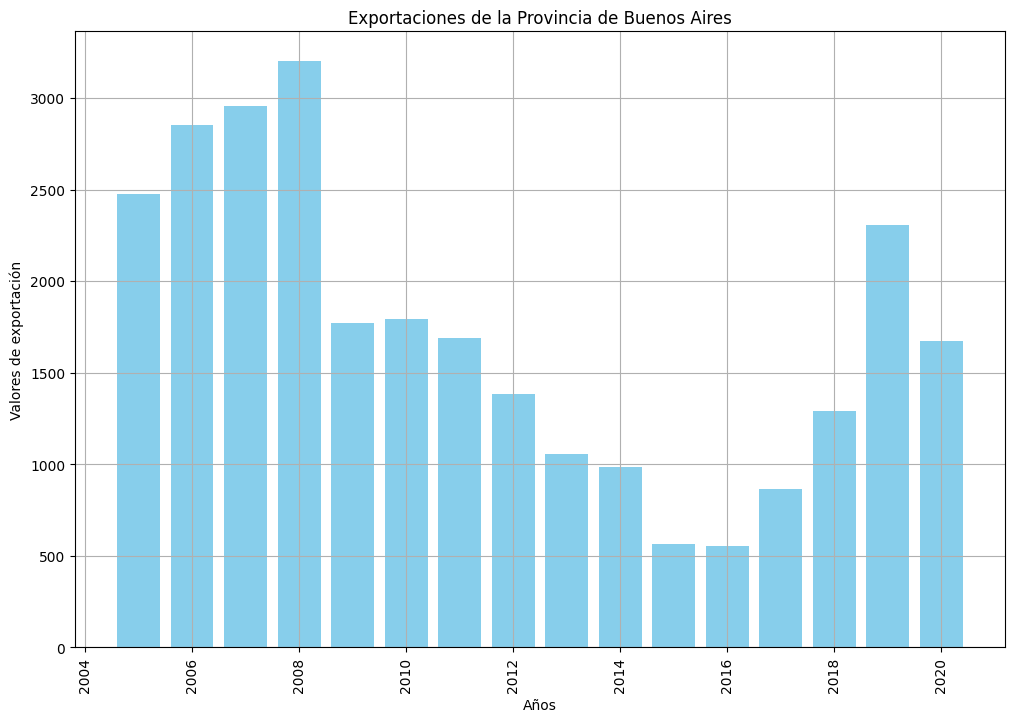

In [ ]:
# grafico de barras de la cantidad de viviendas_particulares_habitadas por provincia
plt.figure(figsize=(12, 8))
#plt.bar(exportaciones_filtrado['value'], exportaciones_filtrado['anio'], color='skyblue') #, edgecolor='black')
plt.bar(exportaciones_ba['anio'], exportaciones_ba['value'], color='skyblue')
plt.title('Exportaciones de la Provincia de Buenos Aires')
plt.xlabel('Años')
plt.ylabel('Valores de exportación')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

### CONVERTIR EL TIPO DE DATO DE LA COLUMNA
### VALUE A NUMERICO PARA QUE PUEDA PROCESARLA

In [ ]:
# convertir el tipo de datos de value a entero
exportaciones_filtrado['value'] = pd.to_numeric(exportaciones_filtrado['value'], errors='coerce')
print(type(exportaciones_filtrado['value']))


<class 'pandas.core.series.Series'>


<ipython-input-72-7a072eb75dc2>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exportaciones_filtrado['value'] = pd.to_numeric(exportaciones_filtrado['value'], errors='coerce')


### SEPARO LAS PROVINCIAS QUE SON PRODUCTORAS DE COMBUSTIBLE
### PARA PODER ANALIZAR AQUELLAS QUE SON PRODUCTORAS

In [ ]:
# preparo los datos de las provincias productoras de combustibles
expor_prov = exportaciones_filtrado.loc[:, (exportaciones_filtrado != 0.000).any()]

print(expor_prov)



                       rubro     provincia  anio     value
101   Combustibles y energía  Buenos Aires  2005  2478.212
105   Combustibles y energía      La Pampa  2005    23.334
106   Combustibles y energía      Santa Fe  2005   215.200
107   Combustibles y energía        Chubut  2005  1254.520
108   Combustibles y energía       Neuquén  2005   819.647
...                      ...           ...   ...       ...
1990  Combustibles y energía         Salta  2020    19.106
1992  Combustibles y energía       Tucumán  2020     1.498
1993  Combustibles y energía       Mendoza  2020    33.993
1997  Combustibles y energía    Corrientes  2020   373.938
1998  Combustibles y energía       Formosa  2020     5.169

[200 rows x 4 columns]


### USO PIVOR PARA REALIZAR EL PRIMER GRAFICO

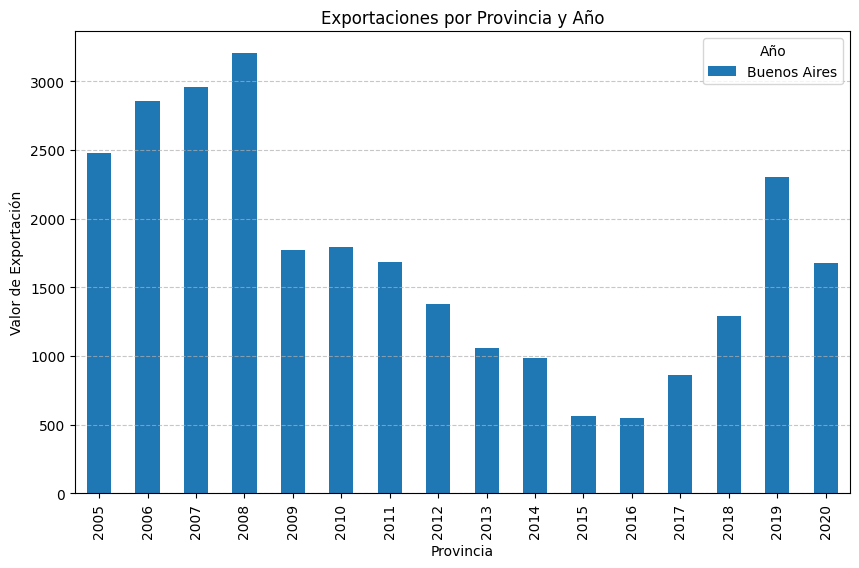

In [ ]:



# crear la tabla pivot
pivot_data = exportaciones_ba.pivot(index='anio', columns='provincia', values='value')

# Crear gráfico de barras

pivot_data.plot(kind='bar', figsize=(10, 6))

plt.title("Exportaciones por Provincia y Año")
plt.xlabel("Provincia")
plt.ylabel("Valor de Exportación")
plt.legend(title="Año")
plt.xticks(rotation=90)  # Rotar nombres de provincias para mayor legibilidad
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



### ARMO UN GRAFICO DE DISPERSION

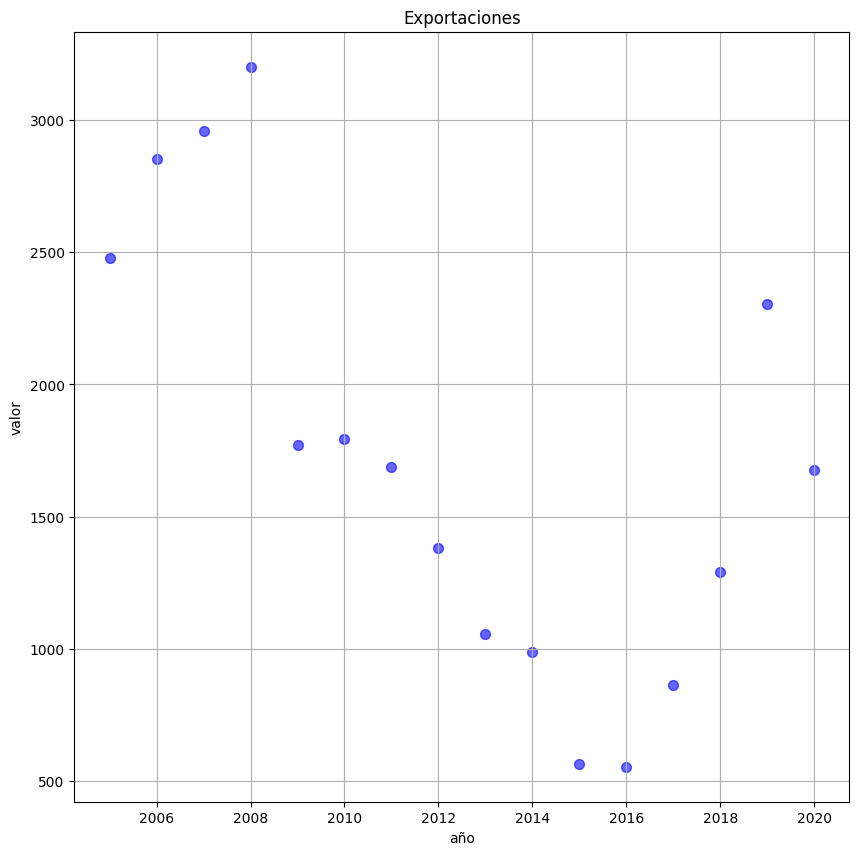

In [ ]:
# diagrama de dispesion

# Podemos cambiar el tamaño del grafico
charScat=plt.figure(figsize=[10,10])

# Definimos el tipo de grafico y las variables
plt.scatter(exportaciones_ba["anio"], exportaciones_ba["value"], alpha=0.6, s=50, c='blue')

# definimos los titulos de los ejes
plt.xlabel("año"); plt.ylabel("valor")

# titulo del grafico
plt.title("Exportaciones")

# Agrego lineas cuadriculada
plt.grid()

charScat.savefig("scatterplot_exportaciones.png")